# PROD Data Analizi

Bu notebookta .csv dosyası olarak alınan input dosyası için:
- FILE_SIZE ve NUMBER_OF_RECORDS sütunlarının ilişkisi incelenir.
- 3 farklı kategorideki veriler için boyut/trend analizi yapılır.
- REGEX_ERROR_COUNT değişkeni kullanılarak error sayısının trend analizi yapılır.

FILE_SIZE ve NUMBER_OF_RECORDS sütunlarının orantısına göre analiz sırasında hangi değişkenin dosya boyutu olarak kullanılacağı kararlaştırılır, analiz sonuçlarına (düzenli trend sayısı, ani iniş veya çıkışların varlığı) bakılarak validasyon için kullanılacak olan yapay zeka modeli seçilir.

In [131]:
import pandas as pd # veri manipulasyonu
import numpy as np # sayisal islemler
import matplotlib.pyplot as plt # gorsellestirme

# dataframe display ayarlari
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)


## Data Yüklemesi

Input dosyası .csv formatındadır ve aşağıdaki sütunları içermesi beklenir: 

    ID, FILE_TP_ID, FILE_NAME, FILE_STATUS,	FILE_SIZE, NUMBER_OF_RECORDS,	REGEX_ERROR_COUNT

Dosyasının eksik olup olmaması ve sütunları hakkında varsayım yapılmaz, dosya kontrollerden geçirilir.

In [132]:
CSV_PATH = "/kaggle/input/datasets/aycaatac/prod-data/import_file_output.csv"


In [133]:
df_base = pd.read_csv(CSV_PATH) # .csv dosyasi data frame olarak yuklenir
df_base.shape # satir ve sutun sayisi kontrol


(4927, 10)

In [134]:
# icerisinde ',' bulunan sayisal veriler ',' karakterinden arindirilir
numeric_cols = ['ID', 'FILE_SIZE', 'NUMBER_OF_RECORDS']

for col in numeric_cols:
    df_base[col] = pd.to_numeric(
        df_base[col].astype(str).str.replace(',', ''), 
        errors='coerce' # parse hatalarinda deger NaN'e cevrilir
    )

In [135]:
# data icerik ve formati kontrol edilir
df_base.head()


,ID,FILE_TP_ID,FILE_NAME,FILE_STATUS,FILE_SIZE,NUMBER_OF_RECORDS,REGEX_ERROR_COUNT,ERROR_DESCRIPTION,PROCESSED_DATE,CREATE_DATE
0,6270,3,AVEA_MCKS_EBL_20260216061501.xml,I,235,4699455,4,NaN,"16/02/2026 10:00:04,616000","16/02/2026 10:00:04,616000"
1,6269,2,BTK_MCKS_SL_20260215221502.xml,S,10187,227030459,1,NaN,"16/02/2026 01:49:14,808000","16/02/2026 01:01:54,889000"
2,6268,1,BTK_MCKS_BL_20260215221502.xml,S,6956,260484793,0,NaN,"16/02/2026 01:49:14,767000","16/02/2026 01:01:31,173000"
3,6267,2,BTK_MCKS_SL_20260215141501.xml,S,10185,226965935,1,NaN,"15/02/2026 17:50:52,275000","15/02/2026 17:01:58,394000"
4,6266,1,BTK_MCKS_BL_20260215141501.xml,S,6956,260485438,0,NaN,"15/02/2026 17:50:52,241000","15/02/2026 17:01:33,516000"


## Tablo Kontrolü

Parsing/mapping hatalarını önlemek için sütun tipleri ve içerikleri kontrol edilir. Tüm kayıtların veya yalnızca successful kayıtların analizinin yapılması için bir değişken tanımlanır. 

In [136]:
# data tipleri kontrol edilir
df_base.dtypes


ID                    int64
FILE_TP_ID            int64
FILE_NAME            object
FILE_STATUS          object
FILE_SIZE             int64
NUMBER_OF_RECORDS     int64
REGEX_ERROR_COUNT     int64
ERROR_DESCRIPTION    object
PROCESSED_DATE       object
CREATE_DATE          object
dtype: object

In [137]:
# sayisal olmasi gereken degerler sayisala cevrilir ve file status alani temizlenir
df_base["FILE_TP_ID"] = pd.to_numeric(df_base["FILE_TP_ID"], errors="coerce")
df_base["FILE_SIZE"] = pd.to_numeric(df_base["FILE_SIZE"], errors="coerce")
df_base["NUMBER_OF_RECORDS"] = pd.to_numeric(df_base["NUMBER_OF_RECORDS"], errors="coerce")
df_base["REGEX_ERROR_COUNT"] = pd.to_numeric(df_base["REGEX_ERROR_COUNT"], errors="coerce")
df_base["FILE_STATUS"] = df_base["FILE_STATUS"].astype(str).str.upper().str.strip()
df_base.shape


(4927, 10)

In [138]:
# sadece successful kayitlarin kullanilmasi icin bir variable
USE_ONLY_TRAINING_DATA = True


In [139]:
# kayitlar icerisinden successful ve sonu .gz ile bitmeyen satirlar secilir
df = df_base.copy()

if USE_ONLY_TRAINING_DATA:
    df = df[
        (df["FILE_STATUS"] == "S") &
        (~df["FILE_NAME"].str.endswith(".gz", na=False))
    ]


## Eksik Data Analizi

Eksik data analizi:

- içerisinde null değerler bulunduran alanları tespit etmek,
- modellemeye uygun olmayan alanları tespit etmek,
- data kalitesini incelemek
  
için yapılır.

In [140]:
# sutunlar NaN degerler icin kontrol edilir, her sutundaki NaN orani kontrol edilir
df.isna().mean().sort_values(ascending=False)


ERROR_DESCRIPTION    0.998972
ID                   0.000000
FILE_TP_ID           0.000000
FILE_NAME            0.000000
FILE_SIZE            0.000000
FILE_STATUS          0.000000
NUMBER_OF_RECORDS    0.000000
REGEX_ERROR_COUNT    0.000000
PROCESSED_DATE       0.000000
CREATE_DATE          0.000000
dtype: float64

## Kategori ve File Status Kontrolü

In [141]:
# dosya ve kategori tipleri teyit edilir
df["FILE_TP_ID"].value_counts().sort_index()


FILE_TP_ID
1    1621
2    1624
3    1621
Name: count, dtype: int64

## FILE_SIZE ve NUMBER_OF_RECORDS İlişkisi 

Dosya boyutu değerlendirilirken hangi sütunun kullanılacağına karar vermek için iki sütunun tamamen doğru orantı içerisinde olup olmadığı kontrol edilir. Dosya boyutunu değerlendirmek için kullanılacak olan değişken tanımlanır ve FILE_SIZE veya NUMBER_OF_RECORDS'a eşitlenir.

In [142]:
# her dosya kategorisi icin NUMBER_OF_RECORDS ve FILE_SIZE arasındaki korelasyon hesaplanir
df.groupby("FILE_TP_ID")[["NUMBER_OF_RECORDS","FILE_SIZE"]].corr()


NUMBER_OF_RECORDS  FILE_SIZE
FILE_TP_ID                                                
1          NUMBER_OF_RECORDS           1.000000   0.999999
           FILE_SIZE                   0.999999   1.000000
2          NUMBER_OF_RECORDS           1.000000   0.999992
           FILE_SIZE                   0.999992   1.000000
3          NUMBER_OF_RECORDS           1.000000   0.999887
           FILE_SIZE                   0.999887   1.000000

In [143]:
# global korelasyon kontrol edilir
df[["NUMBER_OF_RECORDS","FILE_SIZE"]].corr()


,NUMBER_OF_RECORDS,FILE_SIZE
NUMBER_OF_RECORDS,1.000000,0.900721
FILE_SIZE,0.900721,1.000000


In [144]:
# hangi degiskenin dosya boyutuna bakmak icin kullanilacagina karar verilir
VOLUME_COL = "NUMBER_OF_RECORDS"
df["VOLUME_SIGNAL"] = df[VOLUME_COL]


## Kategorilere Göre Data Analizi

Her kategori için ayrı ayrı trend analizi yapılır.

In [145]:
# var olan kategoriler cikartilir
categories = sorted(df["FILE_TP_ID"].dropna().unique())
categories


[np.int64(1), np.int64(2), np.int64(3)]

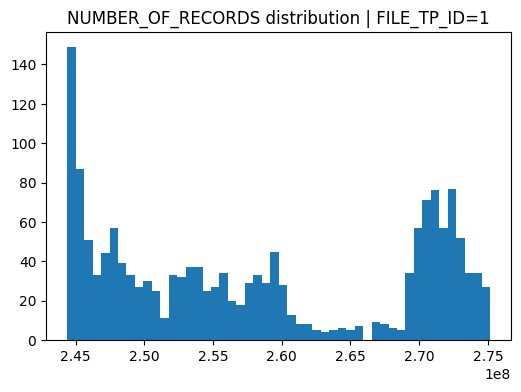

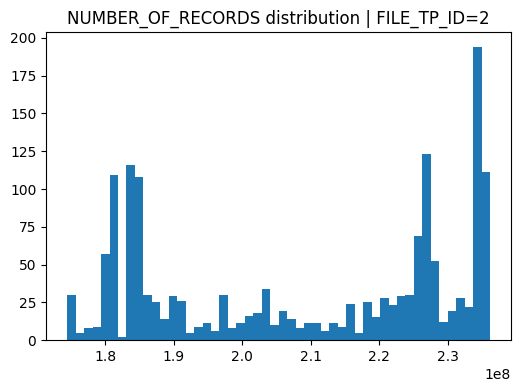

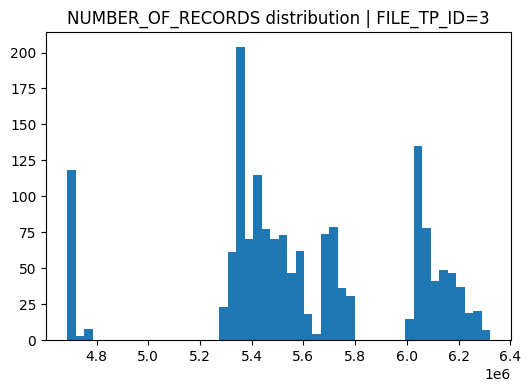

In [146]:
# her kategori icin histogram cizilir - x: NUMBER_OF_RECORDS y: frequency (kac dosya o aralikta)
for tp in categories:
    subset = df[df["FILE_TP_ID"] == tp]
    plt.figure(figsize=(6,4))
    plt.hist(subset["VOLUME_SIGNAL"].dropna(), bins=50)
    plt.title(f"{VOLUME_COL} distribution | FILE_TP_ID={tp}")
    plt.show()


In [147]:
# her kategori icin dosya sayisi, ortalama record sayisi, standart sapma vs. hesaplanir
df.groupby("FILE_TP_ID")["VOLUME_SIGNAL"].describe()


,count,mean,std,min,25%,50%,75%,max
FILE_TP_ID,,,,,,,,
1,1621.0,2.582315e+08,1.065445e+07,244389610.0,2.479995e+08,255904364.0,2.703821e+08,275147739.0
2,1624.0,2.091012e+08,2.140926e+07,174446103.0,1.849010e+08,215038121.0,2.281643e+08,236166283.0
3,1621.0,5.603358e+06,3.990309e+05,4686635.0,5.368322e+06,5526891.0,6.035068e+06,6321461.0


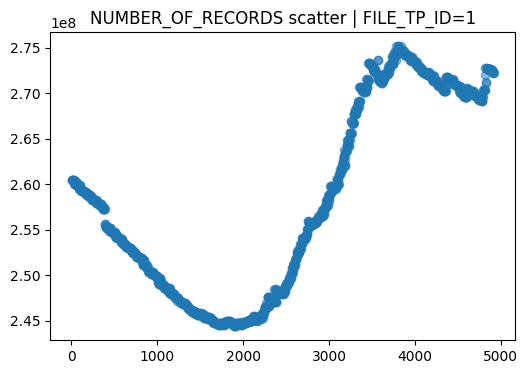

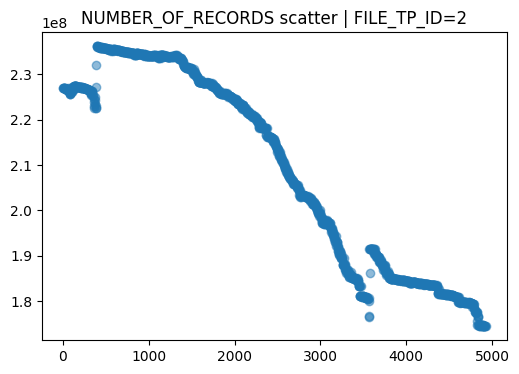

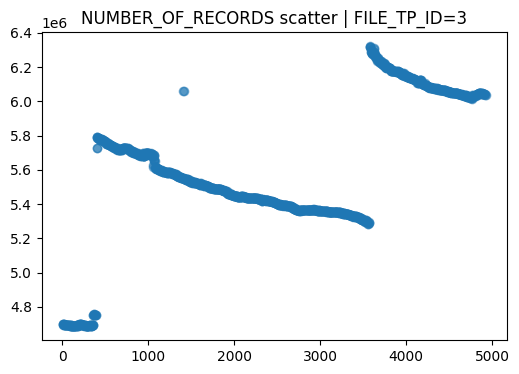

In [148]:
# verilerin zaman boyunca nasil degistigini gozlemlemek icin scatter plot olusturulur
# x: verinin zaman sirasi, y: NUMBER_OF_RECORDS
for tp in categories:
    subset = df[df["FILE_TP_ID"] == tp]
    plt.figure(figsize=(6,4))
    plt.scatter(
        subset.index,
        subset["VOLUME_SIGNAL"],
        alpha=0.5
    )
    plt.title(f"{VOLUME_COL} scatter | FILE_TP_ID={tp}")
    plt.show()


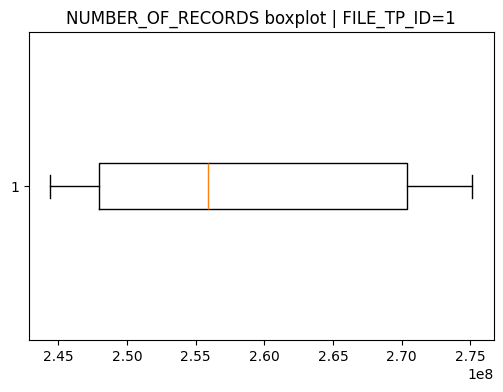

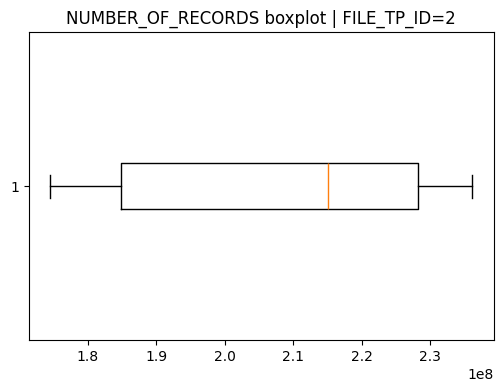

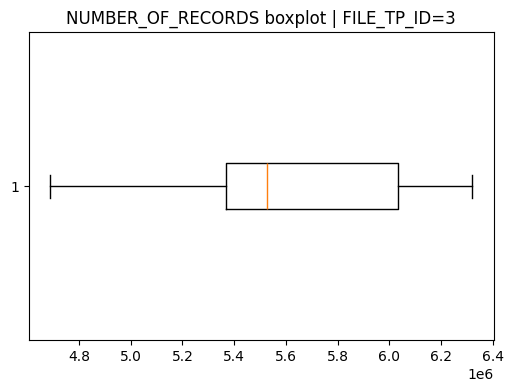

In [149]:
# her kategori icin NUMBER_OF_RECORDS kullanilarak boxplot olusturulur
# distributioni ve global threshold olusturulup olusturulamayacagini gosterir
for tp in categories:
    subset = df[df["FILE_TP_ID"] == tp]
    plt.figure(figsize=(6,4))
    plt.boxplot(subset["VOLUME_SIGNAL"].dropna(), vert=False)
    plt.title(f"{VOLUME_COL} boxplot | FILE_TP_ID={tp}")
    plt.show()

In [150]:
# FILE_NAME sutunundan FILE_TIMESTAMP ve FILE_DATE sutunu olusturulur
df["FILE_TIMESTAMP"] = pd.to_datetime(
    df["FILE_NAME"].str.extract(r"(\d{14})")[0],
    format="%Y%m%d%H%M%S"
)

df = df.sort_values("FILE_TIMESTAMP")
df["FILE_DATE"] = df["FILE_TIMESTAMP"].dt.date


# kayitlar FILE_DATE'e gore sortlanir
df = df.sort_values("FILE_DATE")

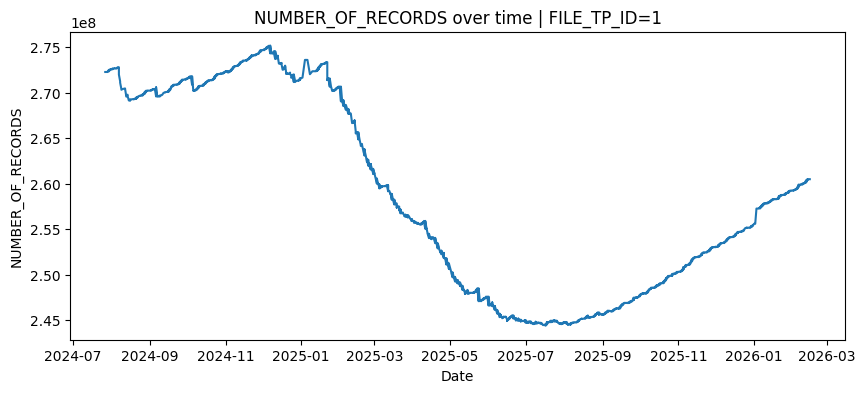

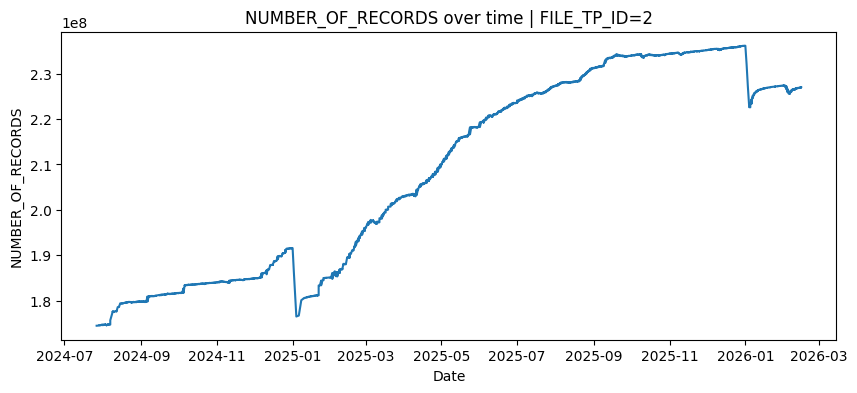

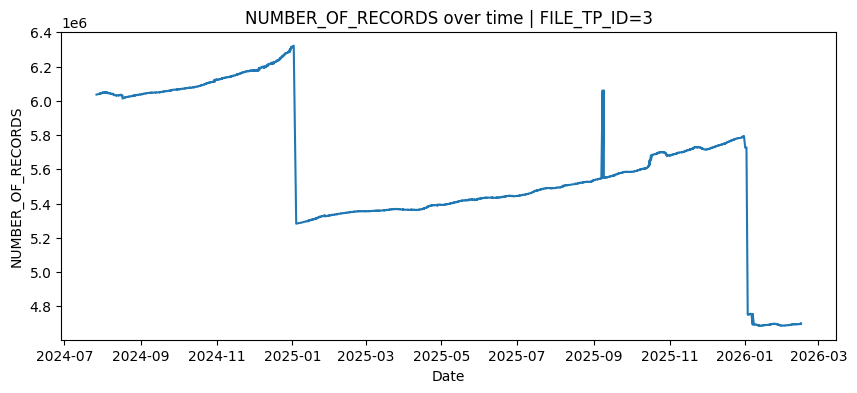

In [151]:
# LEVEL icin NUMBER_OF_RECORDS ve zaman grafigi olusturulur
for tp in categories:
    subset = df[df["FILE_TP_ID"] == tp]
    plt.figure(figsize=(10,4))
    plt.plot(subset["FILE_DATE"], subset["VOLUME_SIGNAL"])
    plt.title(f"{VOLUME_COL} over time | FILE_TP_ID={tp}")
    plt.xlabel("Date")
    plt.ylabel(VOLUME_COL)
    plt.show()

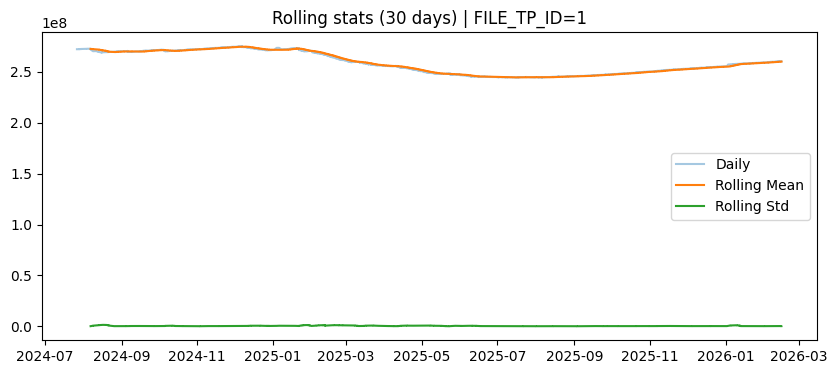

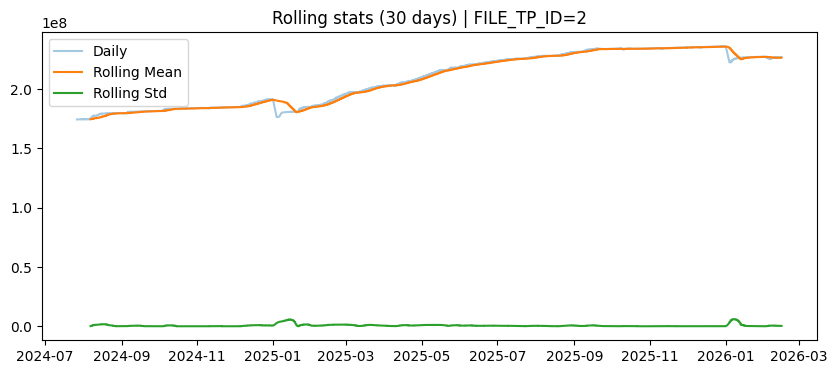

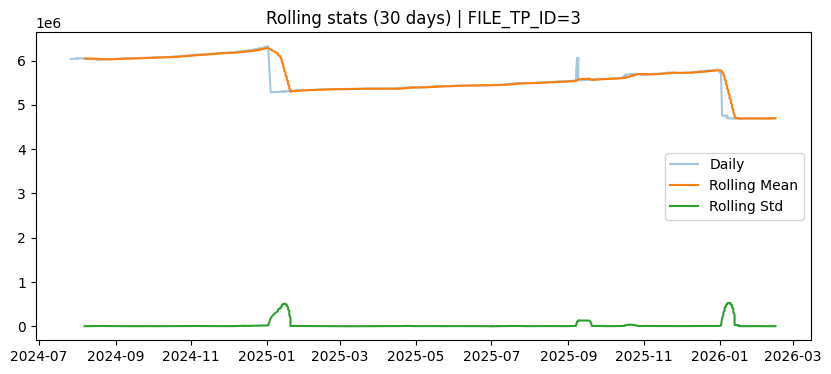

In [152]:
window = 30 # son 30 gun incelenir

# son 30 gunun ortalama ve oynakligina bakilir
for tp in categories:
    subset = df[df["FILE_TP_ID"] == tp].set_index("FILE_DATE")

    plt.figure(figsize=(10,4))
    plt.plot(subset["VOLUME_SIGNAL"], alpha=0.4, label="Daily")
    plt.plot(subset["VOLUME_SIGNAL"].rolling(window).mean(), label="Rolling Mean")
    plt.plot(subset["VOLUME_SIGNAL"].rolling(window).std(), label="Rolling Std")

    plt.title(f"Rolling stats ({window} days) | FILE_TP_ID={tp}")
    plt.legend()
    plt.show()

In [153]:
# Z-score normalization uygulanir ve olcekler esitlenir
df_norm = df.copy()

df_norm["VOLUME_NORM"] = (
    df_norm.groupby("FILE_TP_ID")["VOLUME_SIGNAL"]
    .transform(lambda x: (x - x.mean()) / x.std())
)


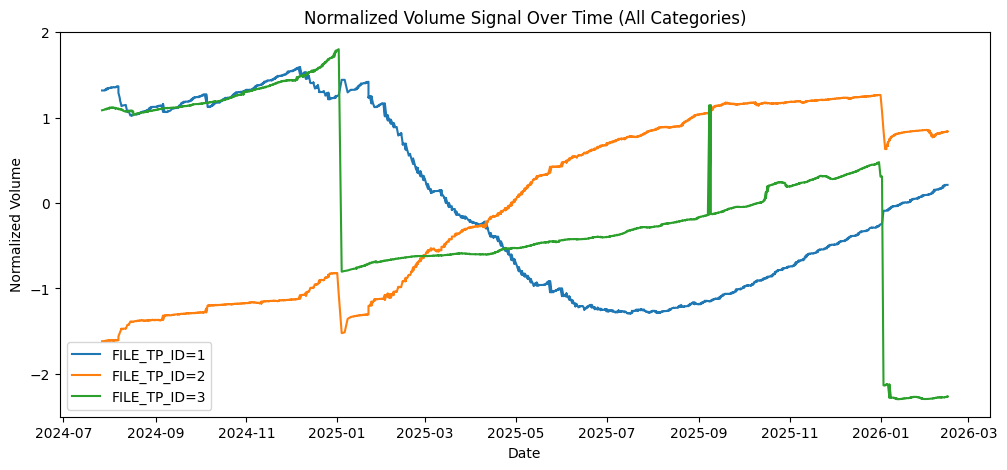

In [154]:
# kategorilerdeki normalize edilmis degerlerin ayni olcekte karsilastirilmasi x: date y: kategorinin 
# +- std arttirilmis degerleri
plt.figure(figsize=(12,5))

for tp in categories:
    subset = df_norm[df_norm["FILE_TP_ID"] == tp]
    plt.plot(
        subset["FILE_DATE"],
        subset["VOLUME_NORM"],
        label=f"FILE_TP_ID={tp}"
    )

plt.title("Normalized Volume Signal Over Time (All Categories)")
plt.xlabel("Date")
plt.ylabel("Normalized Volume")
plt.legend()
plt.show()


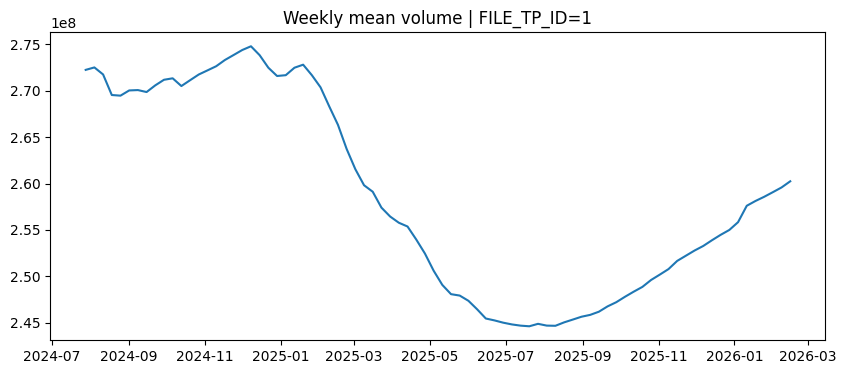

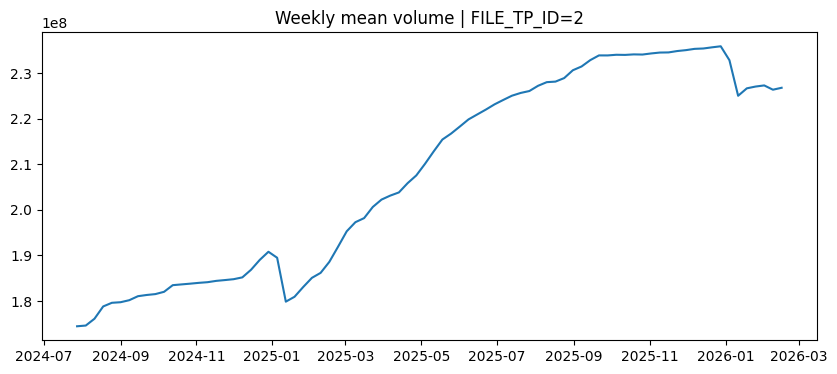

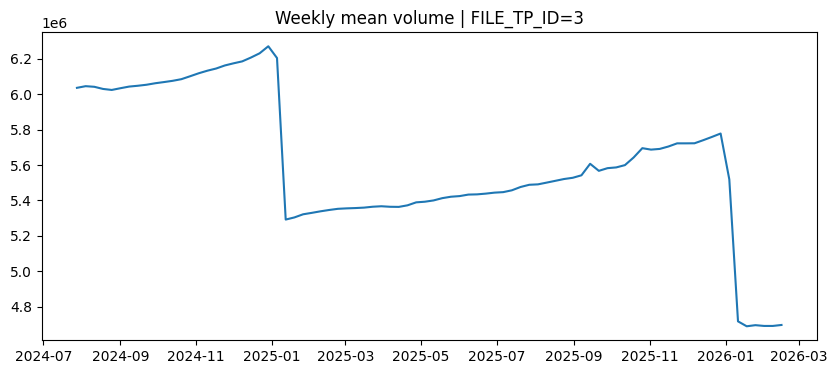

In [155]:
# haftalik ortalama ve trend analizi
df["FILE_DATE"] = pd.to_datetime(df["FILE_DATE"], errors="coerce")

for tp in categories:
    subset = df[df["FILE_TP_ID"] == tp].copy()
    subset = subset.sort_values("FILE_DATE")
    subset = subset.set_index("FILE_DATE")

    weekly = subset["VOLUME_SIGNAL"].resample("W").mean()

    plt.figure(figsize=(10,4))
    plt.plot(weekly)
    plt.title(f"Weekly mean volume | FILE_TP_ID={tp}")
    plt.show()


## REGEX_ERROR_COUNT Analizi

Error sayısı için trend analizi yapılır. Kategoriler ve dosya büyüklüğü ile error sayısı orantısı incelenir.

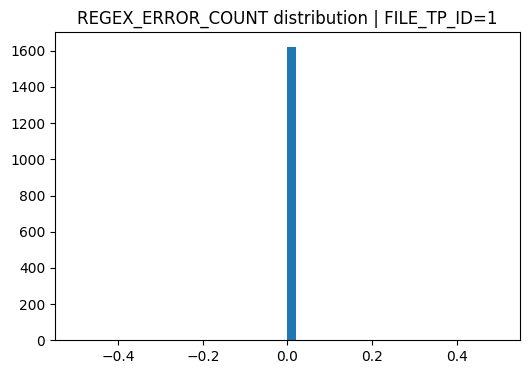

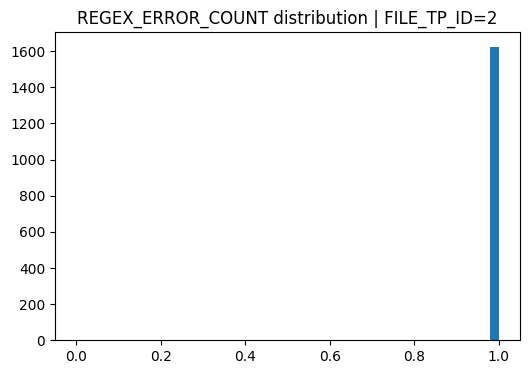

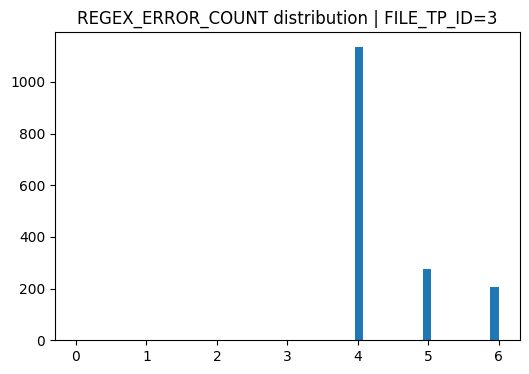

In [157]:
# kategorilere gore REGEX_ERROR_COUNT incelemesi, x: error sayısı, y: bu error sayısına sahip olan
# dosya sayısı
for tp in categories:
    subset = df[df["FILE_TP_ID"] == tp]
    plt.figure(figsize=(6,4))
    plt.hist(subset["REGEX_ERROR_COUNT"].dropna(), bins=50)
    plt.title(f"REGEX_ERROR_COUNT distribution | FILE_TP_ID={tp}")
    plt.show()

In [158]:
# her kategorideki dosyalarin yuzde kacinin en az bir hata icerdigine bakilir
df["HAS_REGEX_ERROR"] = df["REGEX_ERROR_COUNT"].fillna(0) > 0
df.groupby("FILE_TP_ID")["HAS_REGEX_ERROR"].mean()

FILE_TP_ID
1    0.000000
2    0.999384
3    0.999383
Name: HAS_REGEX_ERROR, dtype: float64

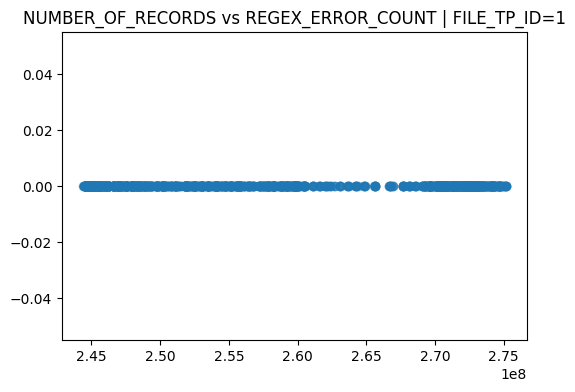

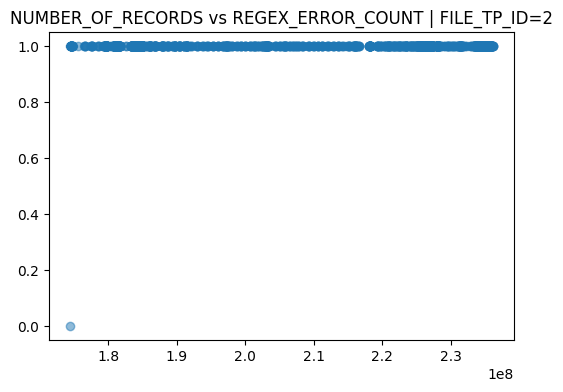

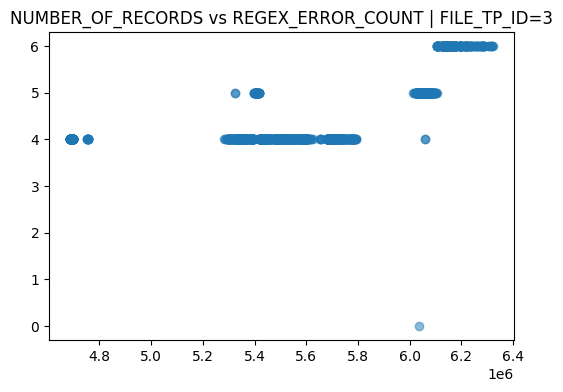

In [159]:
# dosya boyutu ve hata sayisi arasindaki iliski kontrol edilir
for tp in categories:
    subset = df[df["FILE_TP_ID"] == tp]
    plt.figure(figsize=(6,4))
    plt.scatter(
        subset["VOLUME_SIGNAL"],
        subset["REGEX_ERROR_COUNT"],
        alpha=0.5
    )
    plt.title(f"{VOLUME_COL} vs REGEX_ERROR_COUNT | FILE_TP_ID={tp}")
    plt.show()

In [160]:
# her kategori icin dosya buyuklugu ve error sayisi arasindaki Pearson korelasyonu hesaplanir
df.groupby("FILE_TP_ID")[["VOLUME_SIGNAL", "REGEX_ERROR_COUNT"]].corr()


VOLUME_SIGNAL  REGEX_ERROR_COUNT
FILE_TP_ID                                                    
1          VOLUME_SIGNAL           1.000000                NaN
           REGEX_ERROR_COUNT            NaN                NaN
2          VOLUME_SIGNAL           1.000000           0.040192
           REGEX_ERROR_COUNT       0.040192           1.000000
3          VOLUME_SIGNAL           1.000000           0.730345
           REGEX_ERROR_COUNT       0.730345           1.000000

In [161]:
# error sayısı ve error rate ile dosya boyutu arasındaki korelasyonlar kontrol edilir
t3 = df[df["FILE_TP_ID"] == 3].copy()

t3["ERROR_RATE"] = (
    t3["REGEX_ERROR_COUNT"] /
    t3["VOLUME_SIGNAL"]
)

t3[["VOLUME_SIGNAL","REGEX_ERROR_COUNT","ERROR_RATE"]].corr(method="pearson")
t3[["VOLUME_SIGNAL","REGEX_ERROR_COUNT","ERROR_RATE"]].corr(method="spearman")


,VOLUME_SIGNAL,REGEX_ERROR_COUNT,ERROR_RATE
VOLUME_SIGNAL,1.000000,0.735496,0.109788
REGEX_ERROR_COUNT,0.735496,1.000000,0.730546
ERROR_RATE,0.109788,0.730546,1.000000


In [162]:
# error count ve file status arasindaki iliski kontrol edilir
pd.crosstab(
    df["HAS_REGEX_ERROR"],
    df["FILE_STATUS"],
    normalize="index"
)


FILE_STATUS,S
HAS_REGEX_ERROR,
False,1.0
True,1.0


In [163]:
df.groupby("FILE_TP_ID").agg(
    mean_volume=("VOLUME_SIGNAL","mean"),
    std_volume=("VOLUME_SIGNAL","std"),
    mean_errors=("REGEX_ERROR_COUNT","mean"),
    error_rate=("HAS_REGEX_ERROR","mean")
)


,mean_volume,std_volume,mean_errors,error_rate
FILE_TP_ID,,,,
1,2.582315e+08,1.065445e+07,0.000000,0.000000
2,2.091012e+08,2.140926e+07,0.999384,0.999384
3,5.603358e+06,3.990309e+05,4.425046,0.999383


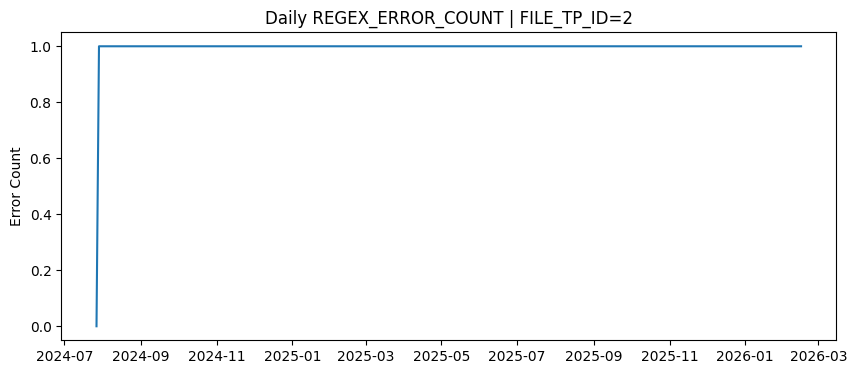

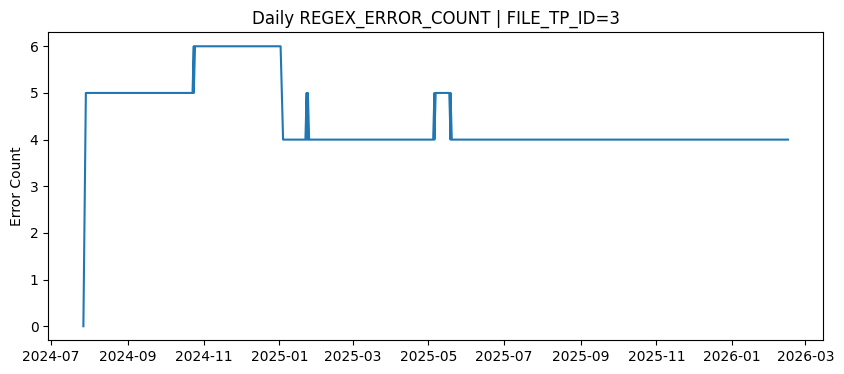

In [164]:
# 2 ve 3. kategorilerin zaman icerisindeki error sayisi gorsellestirilir
for tp in [2, 3]:
    subset = df[df["FILE_TP_ID"] == tp].set_index("FILE_DATE")
    
    plt.figure(figsize=(10,4))
    plt.plot(subset["REGEX_ERROR_COUNT"])
    plt.title(f"Daily REGEX_ERROR_COUNT | FILE_TP_ID={tp}")
    plt.ylabel("Error Count")
    plt.show()


In [165]:
# 3. kategoride bir trend olmasi ihtimaline karsi error sayilari aylara gore incelenir
t3["YEAR_MONTH"] = t3["FILE_DATE"].dt.to_period("M")
t3.groupby("YEAR_MONTH")["REGEX_ERROR_COUNT"].mean()



YEAR_MONTH
2024-07    4.500000
2024-08    5.000000
2024-09    5.000000
2024-10    5.236559
2024-11    6.000000
2024-12    6.000000
2025-01    4.119403
2025-02    4.000000
2025-03    4.000000
2025-04    4.000000
2025-05    4.413043
2025-06    4.000000
2025-07    4.000000
2025-08    4.000000
2025-09    4.000000
2025-10    4.000000
2025-11    4.000000
2025-12    4.000000
2026-01    4.000000
2026-02    4.000000
Freq: M, Name: REGEX_ERROR_COUNT, dtype: float64

## Model Seçimi için Detaylı Analiz

In [166]:
# bir gun icerisinde ayni kategoriden kac dosya geldigi kontrol edilir, ayni gun icinde
# birden fazla dosya varsa, dosyalara FILE_ORDER ile sira numarasi atanir
df = df.sort_values(["FILE_TP_ID", "FILE_DATE", "ID"])
df["FILE_ORDER"] = df.groupby(["FILE_TP_ID", "FILE_DATE"]).cumcount()

print(df["FILE_ORDER"].value_counts().sort_index())

print(df.groupby(["FILE_TP_ID", "FILE_DATE"])["FILE_ORDER"].nunique().value_counts().sort_index())


FILE_ORDER
0    1683
1    1647
2    1536
Name: count, dtype: int64
FILE_ORDER
1      36
2     111
3    1536
Name: count, dtype: int64


In [167]:
# delta kolonları oluşturulur
df["FILE_DATE"] = pd.to_datetime(df["FILE_DATE"], errors="coerce")
df["FILE_TIMESTAMP"] = pd.to_datetime(df["FILE_TIMESTAMP"], errors="coerce")

df_succ = df[df["FILE_STATUS"].eq("S")].copy()
df_succ = df_succ.sort_values(["FILE_TP_ID", "FILE_TIMESTAMP"])

df_succ["DELTA_VOLUME"] = df_succ.groupby("FILE_TP_ID")["VOLUME_SIGNAL"].diff()
df_succ["DELTA_NEGATIVE_FLAG"] = df_succ["DELTA_VOLUME"] < 0

<Figure size 800x400 with 0 Axes>

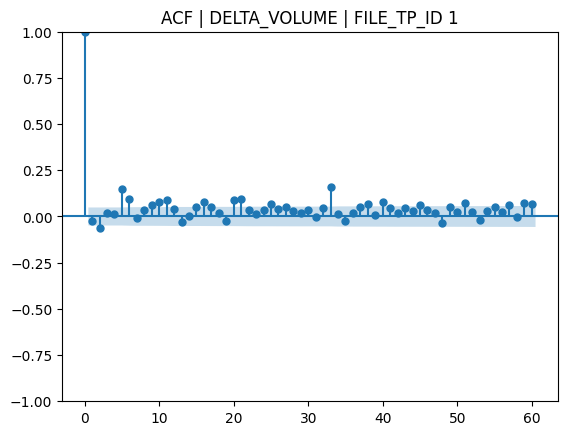

<Figure size 800x400 with 0 Axes>

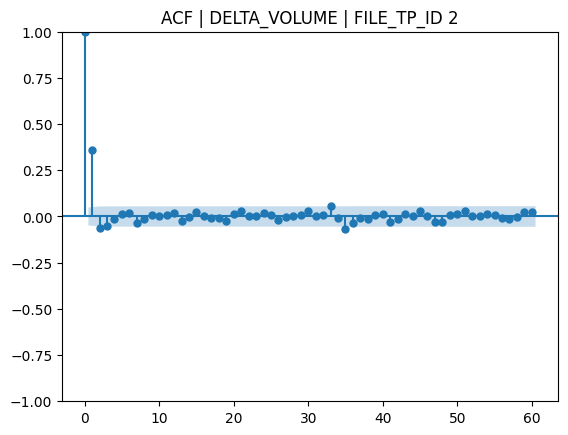

<Figure size 800x400 with 0 Axes>

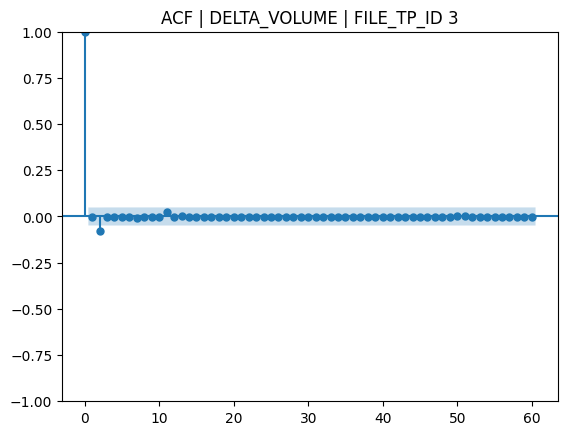

In [168]:
# DELTA_VOLUME kolonunun Autocorrelation Fonksiyonu (ACF) ile serinin gecmis degerleri
# ile ne kadar iliskili olduguna bakilir
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

for tp in sorted(df_succ["FILE_TP_ID"].unique()):
    subset = df_succ[df_succ["FILE_TP_ID"] == tp]
    series = subset["DELTA_VOLUME"].dropna()

    plt.figure(figsize=(8,4))
    plot_acf(series, lags=60)
    plt.title(f"ACF | DELTA_VOLUME | FILE_TP_ID {tp}")
    plt.show()

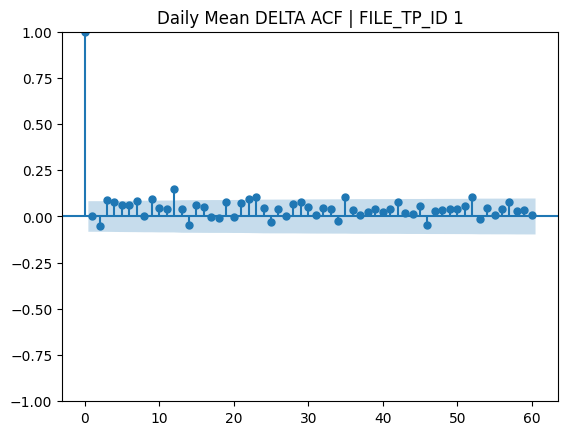

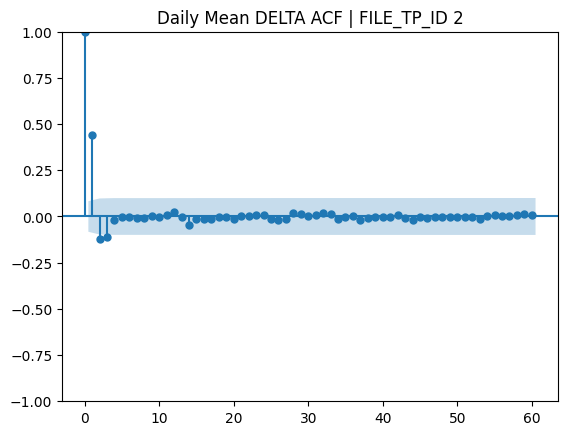

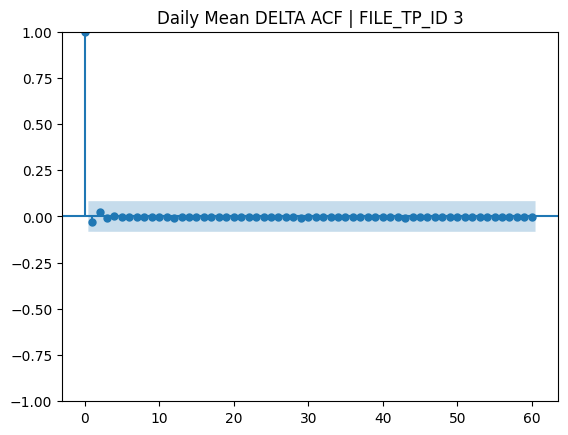

In [169]:
# pearson korelasyonu kullanır - seriyi k adim kaydirip orijinali ile karsilastirir
for tp in sorted(df_succ["FILE_TP_ID"].unique()):
    subset = df_succ[df_succ["FILE_TP_ID"] == tp].copy()
    
    daily_delta = (
        subset.groupby("FILE_DATE")["DELTA_VOLUME"]
        .mean()
        .dropna()
    )
    
    plot_acf(daily_delta, lags=60)
    plt.title(f"Daily Mean DELTA ACF | FILE_TP_ID {tp}")
    plt.show()

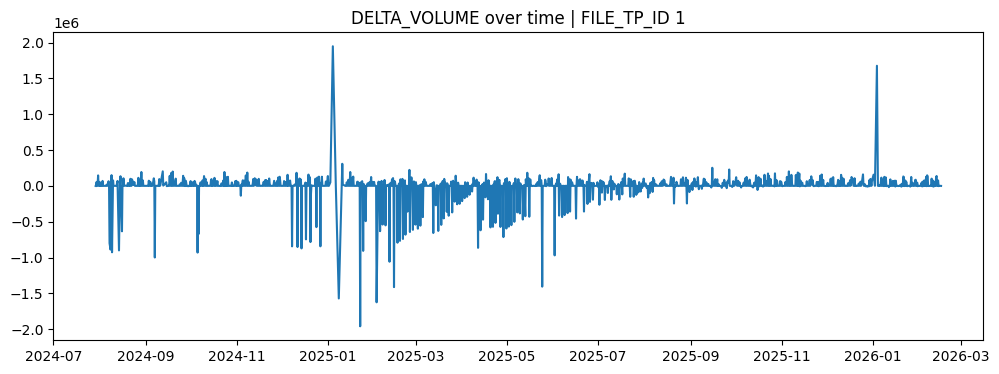

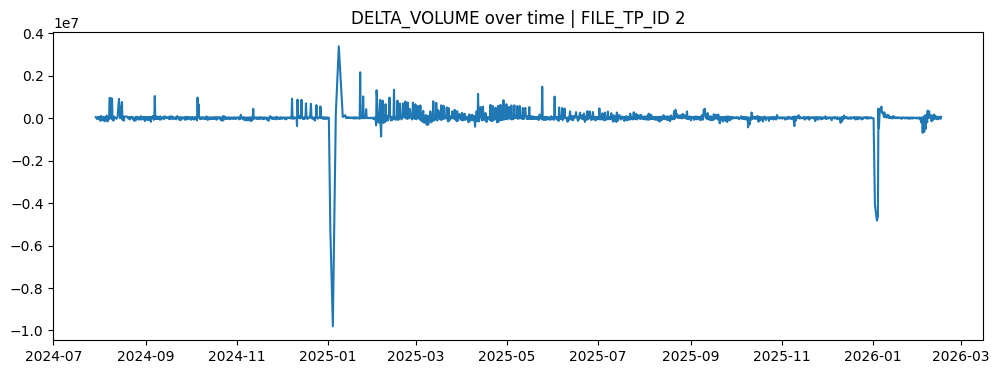

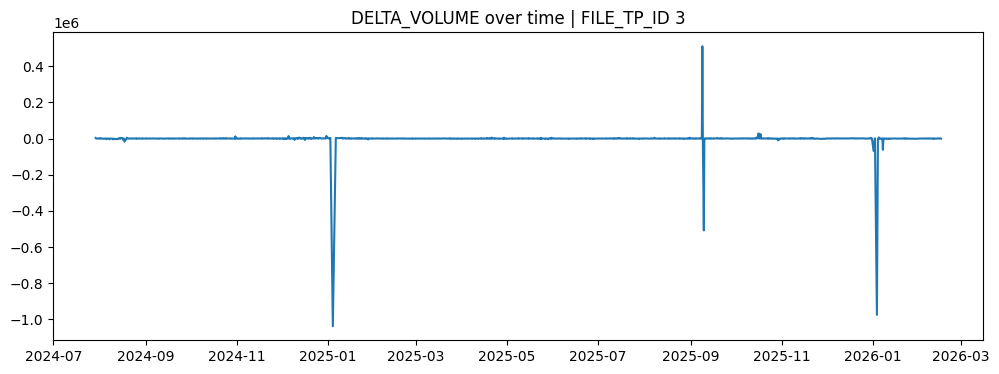

In [170]:
# DELTA_VOLUME kolonunun zaman icindeki davranisi gorsellestirilir
import matplotlib.pyplot as plt

for tp in sorted(df_succ["FILE_TP_ID"].unique()):
    subset = df_succ[df_succ["FILE_TP_ID"] == tp].sort_values("FILE_TIMESTAMP")
    series = subset["DELTA_VOLUME"].dropna()

    plt.figure(figsize=(12,4))
    plt.plot(subset["FILE_TIMESTAMP"][subset["DELTA_VOLUME"].notna()], series)
    plt.title(f"DELTA_VOLUME over time | FILE_TP_ID {tp}")
    plt.show()

In [171]:
# weekly seasonality check - weekday'e gore mean deltaya bakilir

df_succ["WEEKDAY"] = df_succ["FILE_TIMESTAMP"].dt.weekday

for tp in sorted(df_succ["FILE_TP_ID"].unique()):
    subset = df_succ[df_succ["FILE_TP_ID"] == tp]
    weekday_means = subset.groupby("WEEKDAY")["DELTA_VOLUME"].mean()

    print(f"\nFILE_TP_ID {tp}")
    print(weekday_means)


FILE_TP_ID 1
WEEKDAY
0     3532.987288
1     3433.897436
2    -5238.690678
3    14910.594595
4   -10788.446352
5   -19838.428571
6   -36808.052632
Name: DELTA_VOLUME, dtype: float64

FILE_TP_ID 2
WEEKDAY
0    37212.406780
1    44516.670940
2    67414.750000
3    16048.269058
4    52520.136752
5   -17023.051724
6    24369.815789
Name: DELTA_VOLUME, dtype: float64

FILE_TP_ID 3
WEEKDAY
0    2408.622881
1   -1468.461538
2      -1.949153
3     697.752252
4     370.991416
5   -8400.844156
6     603.421053
Name: DELTA_VOLUME, dtype: float64


In [172]:
# monthly seasonality check - month'a gore mean deltaya bakilir

df_succ["YEAR_MONTH"] = df_succ["FILE_TIMESTAMP"].dt.to_period("M")

for tp in sorted(df_succ["FILE_TP_ID"].unique()):
    subset = df_succ[df_succ["FILE_TP_ID"] == tp]
    month_means = subset.groupby("YEAR_MONTH")["DELTA_VOLUME"].mean()

    print(f"\nFILE_TP_ID {tp}")
    print(month_means)


FILE_TP_ID 1
YEAR_MONTH
2024-07     33195.888889
2024-08    -31291.040000
2024-09     15851.524390
2024-10      7991.247312
2024-11     26624.200000
2024-12    -32911.580645
2025-01    -13956.402985
2025-02   -116163.243902
2025-03    -58196.233333
2025-04    -57037.511111
2025-05    -34507.652174
2025-06    -29393.157303
2025-07     -2543.408602
2025-08      9480.043956
2025-09     23051.952941
2025-10     29997.032609
2025-11     31022.919540
2025-12     27117.191011
2026-01     44189.197674
2026-02     27919.600000
Freq: M, Name: DELTA_VOLUME, dtype: float64

FILE_TP_ID 2
YEAR_MONTH
2024-07     25138.222222
2024-08     65621.615385
2024-09     23005.073171
2024-10     24791.505376
2024-11      9815.366667
2024-12     71776.881720
2025-01    -96180.059701
2025-02    133223.512195
2025-03     78005.955556
2025-04     77232.833333
2025-05     90510.163043
2025-06     59278.494382
2025-07     40076.096774
2025-08     43561.879121
2025-09     31334.176471
2025-10      4783.793478
2025-1


FILE_TP_ID 1
Skew: -3.0163542156154755
Kurtosis: 41.654357631166604


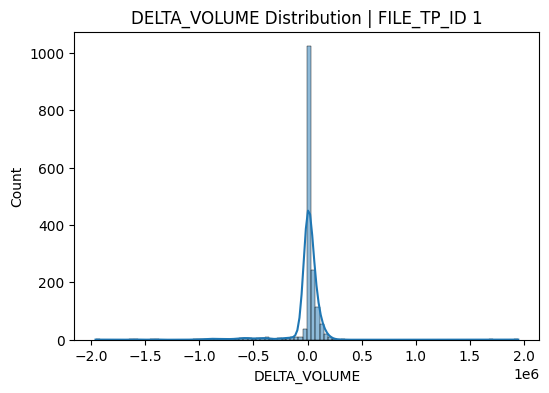


FILE_TP_ID 2
Skew: -13.289896863164177
Kurtosis: 296.8769899464592


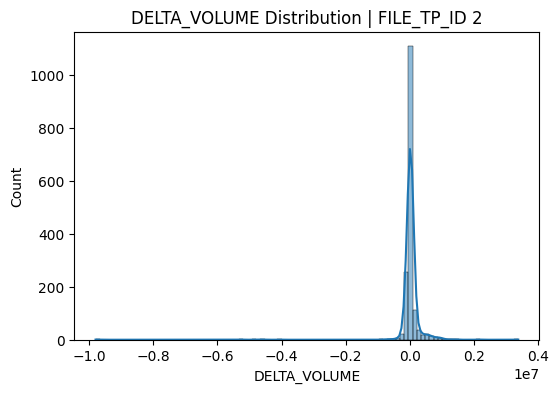


FILE_TP_ID 3
Skew: -20.033261793438136
Kurtosis: 539.4729102790403


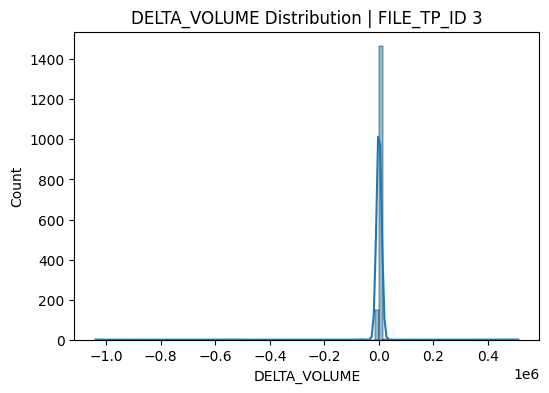

In [173]:
# DELTA_VOLUME kolonunun dagilimi incelenir
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import skew, kurtosis

for tp in sorted(df_succ["FILE_TP_ID"].unique()):
    subset = df_succ[df_succ["FILE_TP_ID"] == tp]
    series = subset["DELTA_VOLUME"].dropna()

    print(f"\nFILE_TP_ID {tp}")
    print("Skew:", skew(series)) #carpiklik, negatif skew ise buyuk dususler buyuk artislardan daha baskin
    print("Kurtosis:", kurtosis(series)) # kurtosis yuksek ise cok uc degisimler yasaniyordur (normal dagilimlarda 3)

    plt.figure(figsize=(6,4))
    sns.histplot(series, bins=100, kde=True)
    plt.title(f"DELTA_VOLUME Distribution | FILE_TP_ID {tp}")
    plt.show()

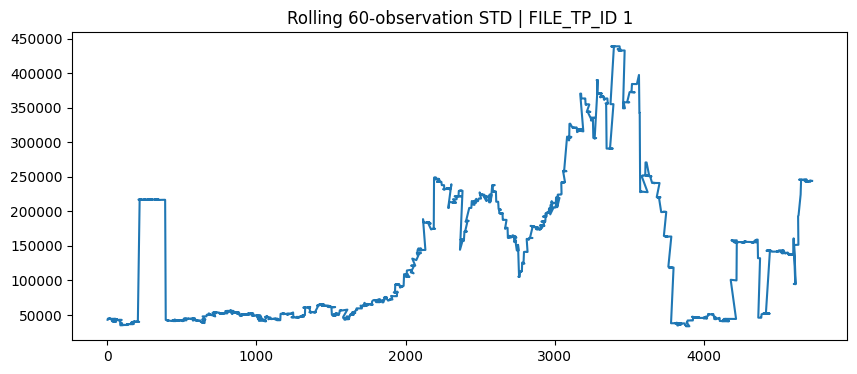

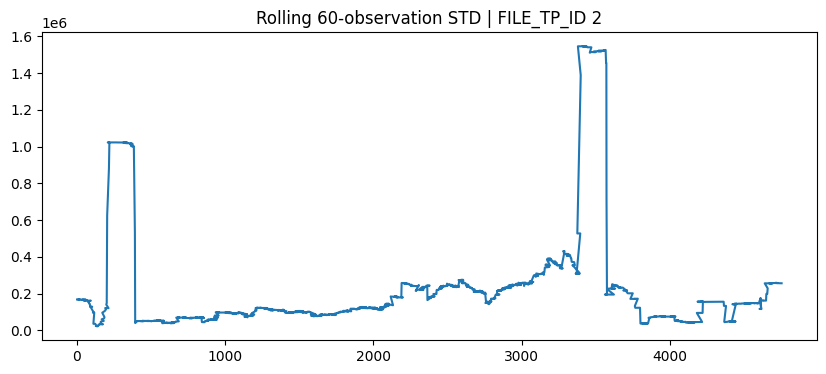

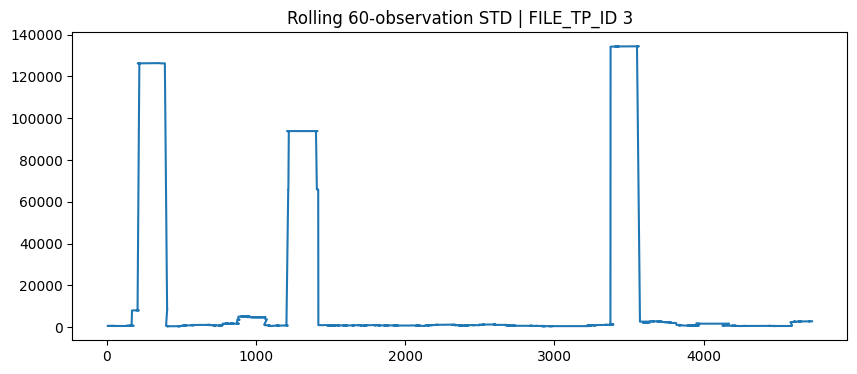

In [174]:
# varyansin zaman ile degisimi incelenir - variance seasonality ihtimaline karsi
for tp in sorted(df_succ["FILE_TP_ID"].unique()):
    subset = df_succ[df_succ["FILE_TP_ID"] == tp].sort_values("FILE_TIMESTAMP")
    series = subset["DELTA_VOLUME"].dropna()

    rolling_std = series.rolling(60).std()

    plt.figure(figsize=(10,4))
    plt.plot(rolling_std)
    plt.title(f"Rolling 60-observation STD | FILE_TP_ID {tp}")
    plt.show()

In [175]:
df["processed_date"] = pd.to_datetime(
    df["PROCESSED_DATE"],
    format="%d/%m/%Y %H:%M:%S,%f"
)

df["create_date"] = pd.to_datetime(
    df["CREATE_DATE"],
    format="%d/%m/%Y %H:%M:%S,%f"
)


In [176]:
df = df.sort_values("processed_date")

df["time_diff_sec"] = df["processed_date"].diff().dt.total_seconds()

df[["FILE_TP_ID", "processed_date", "time_diff_sec"]].head(20)


,FILE_TP_ID,processed_date,time_diff_sec
4926,1,2024-07-28 05:07:06.000,NaN
4924,3,2024-07-28 05:07:06.000,0.000
4925,2,2024-07-28 05:07:06.000,0.000
4915,1,2024-07-29 17:01:19.821,129253.821
4916,2,2024-07-29 17:01:19.854,0.033
4917,3,2024-07-29 17:01:19.869,0.015
4912,1,2024-07-29 20:05:58.096,11078.227
4913,2,2024-07-29 20:05:58.141,0.045
4914,3,2024-07-29 20:05:58.150,0.009
4909,1,2024-07-30 07:20:43.992,40485.842



FILE_TP_ID: 1
Weekday ANOVA p-value: 0.9987
ACF lag 7: 0.984
ACF lag 14: 0.965
Ljung-Box p-value (lag 7): 0.0


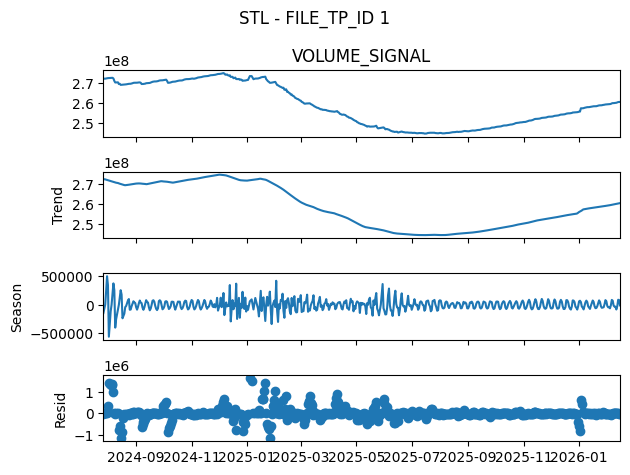


FILE_TP_ID: 2
Weekday ANOVA p-value: 0.995
ACF lag 7: 0.974
ACF lag 14: 0.949
Ljung-Box p-value (lag 7): 0.0


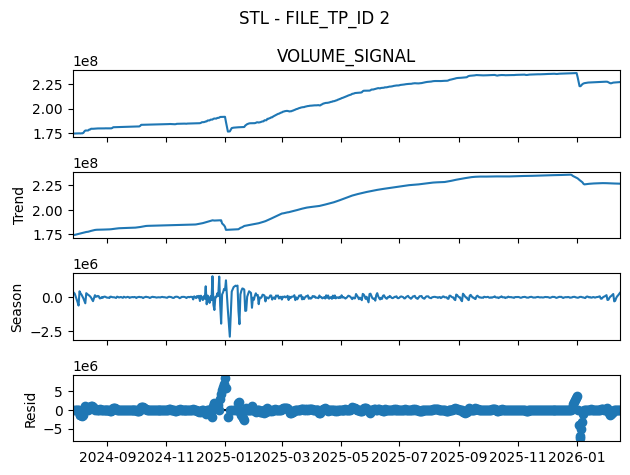


FILE_TP_ID: 3
Weekday ANOVA p-value: 0.9944
ACF lag 7: 0.876
ACF lag 14: 0.753
Ljung-Box p-value (lag 7): 0.0


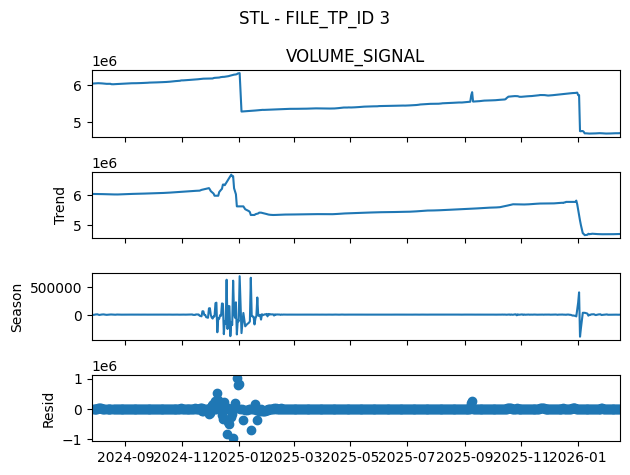

In [177]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.tsa.stattools import acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import STL

for tp in sorted(df["FILE_TP_ID"].unique()):
    
    print(f"\nFILE_TP_ID: {tp}")
    
    subset = df[df["FILE_TP_ID"] == tp].sort_values("FILE_DATE")
    series = subset.groupby("FILE_DATE")["VOLUME_SIGNAL"].mean()
    
    # weekday ANOVA
    subset["WEEKDAY"] = subset["FILE_DATE"].dt.weekday
    groups = [subset[subset["WEEKDAY"] == i]["VOLUME_SIGNAL"].values for i in range(7)]
    groups = [g for g in groups if len(g) > 5]
    
    if len(groups) >= 2:
        f_stat, p_value = stats.f_oneway(*groups)
        print("Weekday ANOVA p-value:", round(p_value, 4))
    
    # ACF
    acf_vals = acf(series.dropna(), nlags=30, fft=True)
    print("ACF lag 7:", round(acf_vals[7], 3))
    print("ACF lag 14:", round(acf_vals[14], 3))
    
    # Ljung box
    lb = acorr_ljungbox(series.dropna(), lags=[7], return_df=True)
    print("Ljung-Box p-value (lag 7):", round(lb["lb_pvalue"].iloc[0], 4))
    
    # STL
    if len(series) > 14:
        stl = STL(series, period=7, robust=True)
        res = stl.fit()
        
        var_resid = np.var(res.resid)
        var_seasonal = np.var(res.seasonal)
        var_trend = np.var(res.trend)
        
        res.plot()
        plt.suptitle(f"STL - FILE_TP_ID {tp}")
        plt.tight_layout()
        plt.show()


FILE_TP_ID: 1
Weekday ANOVA p-value: nan
ACF lag 7: 0.086
ACF lag 14: -0.045
Ljung-Box p-value (lag 7): 0.0112


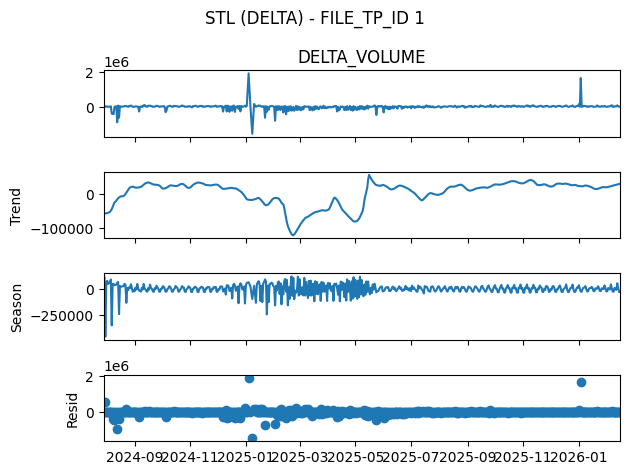


FILE_TP_ID: 2
Weekday ANOVA p-value: nan
ACF lag 7: -0.006
ACF lag 14: -0.044
Ljung-Box p-value (lag 7): 0.0


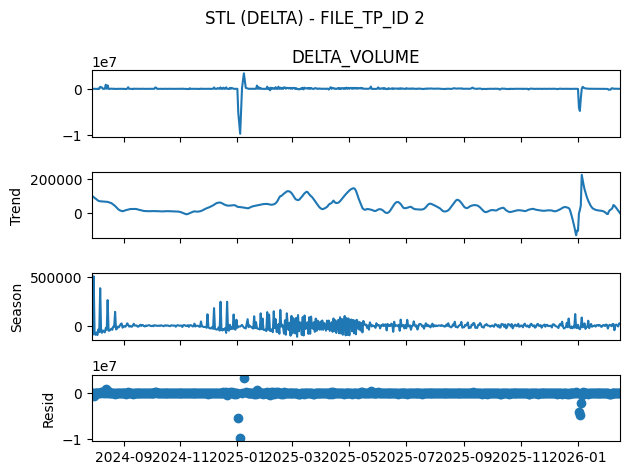


FILE_TP_ID: 3
Weekday ANOVA p-value: nan
ACF lag 7: -0.003
ACF lag 14: -0.004
Ljung-Box p-value (lag 7): 0.997


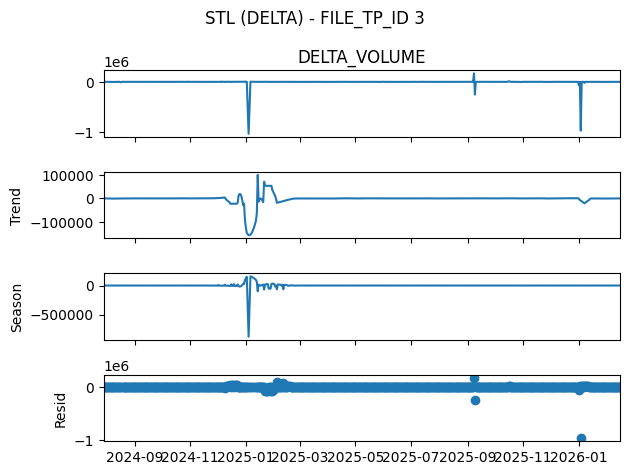

In [178]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.tsa.stattools import acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import STL

for tp in sorted(df_succ["FILE_TP_ID"].unique()):
    
    print("\nFILE_TP_ID:", tp)
    
    subset = df_succ[df_succ["FILE_TP_ID"] == tp].sort_values("FILE_DATE").copy()
    
    # gunluk delta mean
    daily_delta = (
        subset.groupby("FILE_DATE")["DELTA_VOLUME"]
        .mean()
        .dropna()
    )
    
    # weekday ANOVA 
    subset["WEEKDAY"] = subset["FILE_DATE"].dt.weekday
    groups = [
        subset[subset["WEEKDAY"] == i]["DELTA_VOLUME"].values
        for i in range(7)
    ]
    groups = [g for g in groups if len(g) > 5]
    
    if len(groups) >= 2:
        f_stat, p_value = stats.f_oneway(*groups)
        print("Weekday ANOVA p-value:", round(p_value, 4))
    
    # ACF
    acf_vals = acf(daily_delta, nlags=30, fft=True)
    print("ACF lag 7:", round(acf_vals[7], 3))
    print("ACF lag 14:", round(acf_vals[14], 3))
    
    # Ljung-Box
    lb = acorr_ljungbox(daily_delta, lags=[7], return_df=True)
    print("Ljung-Box p-value (lag 7):", round(lb["lb_pvalue"].iloc[0], 4))
    
    # STL
    if len(daily_delta) > 14:
        stl = STL(daily_delta, period=7, robust=True)
        res = stl.fit()
        
        var_resid = np.var(res.resid)
        var_seasonal = np.var(res.seasonal)
        var_trend = np.var(res.trend)
        
        res.plot()
        plt.suptitle(f"STL (DELTA) - FILE_TP_ID {tp}")
        plt.tight_layout()
        plt.show()


FILE_TP_ID: 1


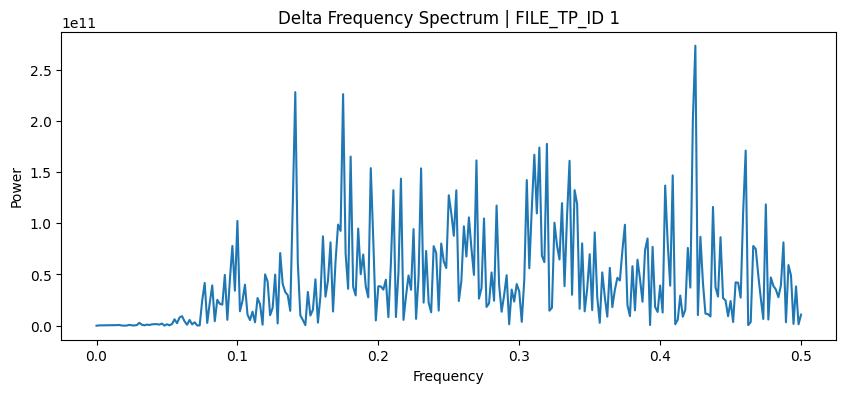


FILE_TP_ID: 2


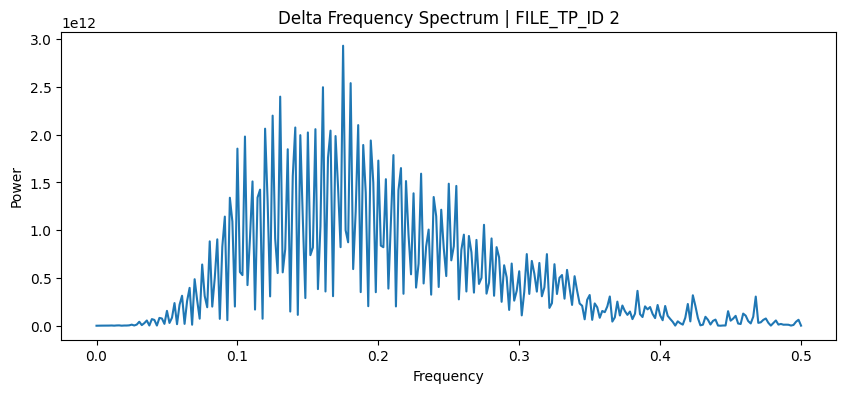


FILE_TP_ID: 3


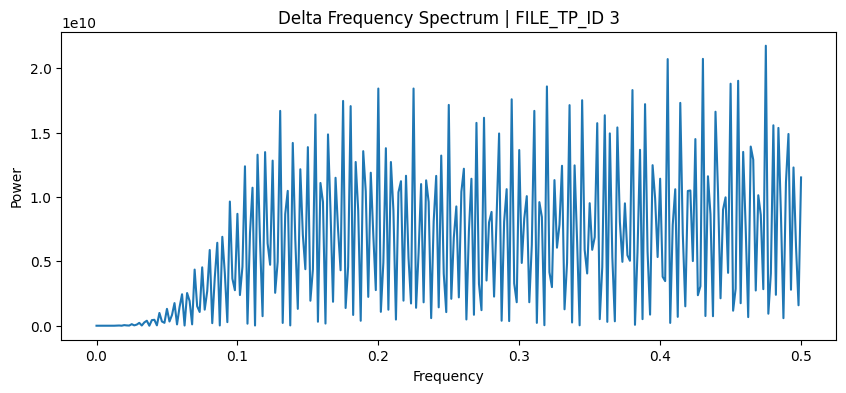

In [179]:
from statsmodels.tsa.seasonal import STL
from scipy.signal import periodogram
import matplotlib.pyplot as plt

# x: 1 / periyot (0.14: haftalik vs.) y: tekrarin ve patternin gucu
for tp in sorted(df_succ["FILE_TP_ID"].unique()):
    
    print("\nFILE_TP_ID:", tp)
    
    subset = df_succ[df_succ["FILE_TP_ID"] == tp].sort_values("FILE_DATE")
    
    daily_delta = (
        subset.groupby("FILE_DATE")["DELTA_VOLUME"]
        .mean()
        .dropna()
    )
    # STL kullanarak deltadan trendi cikariyoruz, residual ve seasonal kaliyor, 
    # ornegin eger weekly seasonality varsa, 1/7 = 0.14 civarlarinda peak bekliyoruz
    if len(daily_delta) > 14:
        
        stl = STL(daily_delta, period=7)
        res = stl.fit()
        
        detrended = daily_delta - res.trend
        
        freqs, power = periodogram(detrended)
        
        plt.figure(figsize=(10,4))
        plt.plot(freqs, power)
        plt.title(f"Delta Frequency Spectrum | FILE_TP_ID {tp}")
        plt.xlabel("Frequency")
        plt.ylabel("Power")
        plt.show()


FILE_TP_ID: 1


<Figure size 800x400 with 0 Axes>

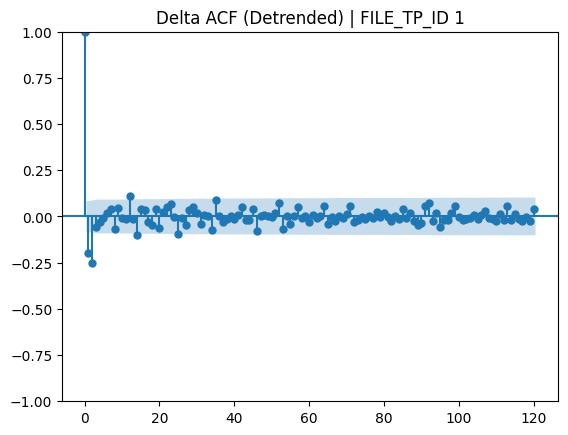


FILE_TP_ID: 2


<Figure size 800x400 with 0 Axes>

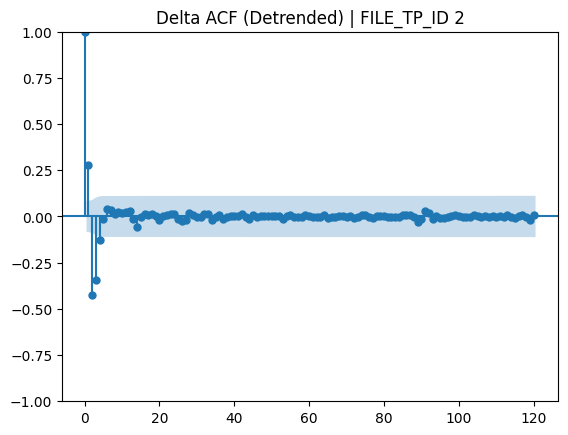


FILE_TP_ID: 3


<Figure size 800x400 with 0 Axes>

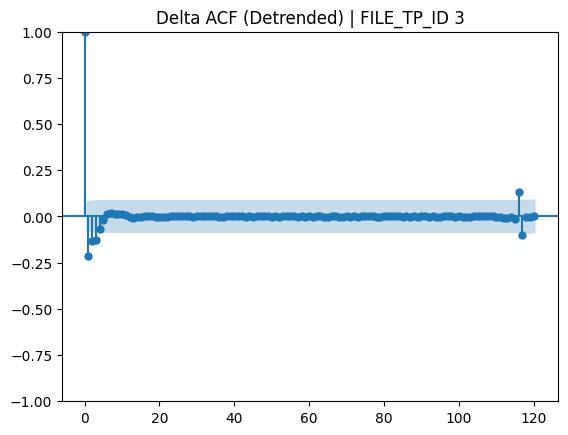

In [180]:
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

for tp in sorted(df_succ["FILE_TP_ID"].unique()):
    
    print("\nFILE_TP_ID:", tp)
    
    subset = df_succ[df_succ["FILE_TP_ID"] == tp].sort_values("FILE_DATE")
    
    daily_delta = (
        subset.groupby("FILE_DATE")["DELTA_VOLUME"]
        .mean()
        .dropna()
    )
    
    if len(daily_delta) > 14:
        
        stl = STL(daily_delta, period=7)
        res = stl.fit()
        
        detrended = daily_delta - res.trend
        
        plt.figure(figsize=(8,4))
        plot_acf(detrended, lags=120)
        plt.title(f"Delta ACF (Detrended) | FILE_TP_ID {tp}")
        plt.show()

In [181]:
from scipy import stats

for tp in sorted(df_succ["FILE_TP_ID"].unique()):
    
    print("\nFILE_TP_ID:", tp)
    
    subset = df_succ[df_succ["FILE_TP_ID"] == tp].copy()
    
    subset["day"] = subset["FILE_DATE"].dt.day
    subset["is_end"] = subset["day"] >= 25
    
    group1 = subset[subset["is_end"]]["DELTA_VOLUME"].dropna()
    group2 = subset[~subset["is_end"]]["DELTA_VOLUME"].dropna()
    
    print("Mean DELTA (days 25-31):", group1.mean())
    print("Mean DELTA (days 1-24):", group2.mean())
    
    if len(group1) > 5 and len(group2) > 5:
        t_stat, p_value = stats.ttest_ind(group1, group2, equal_var=False)
        print("p-value:", p_value)


FILE_TP_ID: 1
Mean DELTA (days 25-31): 5018.081920903955
Mean DELTA (days 1-24): -10706.069510268562
p-value: 0.04748756383717663

FILE_TP_ID: 2
Mean DELTA (days 25-31): 36545.661016949154
Mean DELTA (days 1-24): 31242.86209613869
p-value: 0.6995649327598727

FILE_TP_ID: 3
Mean DELTA (days 25-31): 264.2570621468927
Mean DELTA (days 1-24): -1130.2251184834124
p-value: 0.27160235324760496


In [182]:
# ANOVA ve delta kullanilarak aylar icin ayri ayri seasonality testi

for tp in sorted(df_succ["FILE_TP_ID"].unique()):
    
    subset = df_succ[df_succ["FILE_TP_ID"] == tp].copy()
    subset["MONTH"] = subset["FILE_DATE"].dt.month
    
    print(f"\nFILE_TP_ID {tp}")
    
    month_means = subset.groupby("MONTH")["DELTA_VOLUME"].mean()
    overall_mean = subset["DELTA_VOLUME"].mean()
    
    for m, mean in month_means.items():
        pct = (mean - overall_mean) / overall_mean * 100 if overall_mean != 0 else 0
        print(f"Month {m}: {mean:,.2f} ({pct:+.2f}%)")
    
    groups = [
        subset[subset["MONTH"] == m]["DELTA_VOLUME"].dropna().values
        for m in subset["MONTH"].unique()
    ]
    groups = [g for g in groups if len(g) > 5]
    
    if len(groups) >= 2:
        _, p_value = stats.f_oneway(*groups)
        print("ANOVA p-value:", round(p_value, 4))


FILE_TP_ID 1
Month 1: 18,726.75 (-357.59%)
Month 2: -65,110.27 (+795.60%)
Month 3: -58,196.23 (+700.49%)
Month 4: -57,037.51 (+684.55%)
Month 5: -34,507.65 (+374.65%)
Month 6: -29,393.16 (+304.30%)
Month 7: 610.06 (-108.39%)
Month 8: -8,940.63 (+22.98%)
Month 9: 19,516.41 (-368.45%)
Month 10: 18,934.66 (-360.45%)
Month 11: 28,786.28 (-495.96%)
Month 12: -3,556.85 (-51.08%)
ANOVA p-value: 0.0

FILE_TP_ID 2
Month 1: -99,453.71 (-406.96%)
Month 2: 83,185.46 (+156.75%)
Month 3: 78,005.96 (+140.76%)
Month 4: 77,232.83 (+138.38%)
Month 5: 90,510.16 (+179.36%)
Month 6: 59,278.49 (+82.96%)
Month 7: 38,758.05 (+19.63%)
Month 8: 53,743.30 (+65.88%)
Month 9: 27,244.44 (-15.91%)
Month 10: 14,841.72 (-54.19%)
Month 11: 9,572.27 (-70.46%)
Month 12: 41,957.36 (+29.50%)
ANOVA p-value: 0.0069

FILE_TP_ID 3
Month 1: -13,662.71 (+1555.07%)
Month 2: 274.32 (-133.23%)
Month 3: 108.23 (-113.11%)
Month 4: 308.01 (-137.31%)
Month 5: 393.90 (-147.72%)
Month 6: 169.18 (-120.49%)
Month 7: 553.02 (-166.99%)
Mont

In [183]:
for tp in sorted(df_succ["FILE_TP_ID"].unique()):
    
    print("\nFILE_TP_ID:", tp)
    
    subset = df_succ[df_succ["FILE_TP_ID"] == tp].copy()
    subset["YEAR"] = subset["FILE_DATE"].dt.year
    subset["MONTH"] = subset["FILE_DATE"].dt.month
    
    table = (
        subset
        .groupby(["YEAR", "MONTH"])["DELTA_VOLUME"]
        .mean()
        .unstack(0)  
    )
    
    print(table.round(0))


FILE_TP_ID: 1
YEAR      2024      2025     2026
MONTH                            
1          NaN  -13956.0  44189.0
2          NaN -116163.0  27920.0
3          NaN  -58196.0      NaN
4          NaN  -57038.0      NaN
5          NaN  -34508.0      NaN
6          NaN  -29393.0      NaN
7      33196.0   -2543.0      NaN
8     -31291.0    9480.0      NaN
9      15852.0   23052.0      NaN
10      7991.0   29997.0      NaN
11     26624.0   31023.0      NaN
12    -32912.0   27117.0      NaN

FILE_TP_ID: 2
YEAR      2024      2025      2026
MONTH                             
1          NaN  -96180.0 -102004.0
2          NaN  133224.0   -7995.0
3          NaN   78006.0       NaN
4          NaN   77233.0       NaN
5          NaN   90510.0       NaN
6          NaN   59278.0       NaN
7      25138.0   40076.0       NaN
8      65622.0   43562.0       NaN
9      23005.0   31334.0       NaN
10     24792.0    4784.0       NaN
11      9815.0    9321.0       NaN
12     71777.0   10798.0       NaN

FIL

In [184]:
# ANOVA ve delta kullanilarak ay ici donem seasonality testi
from scipy import stats

print("\nMonthly seasonality - month period (DELTA)")

for tp in sorted(df_succ["FILE_TP_ID"].unique()):
    
    subset = df_succ[df_succ["FILE_TP_ID"] == tp].copy()
    subset["DAY"] = subset["FILE_DATE"].dt.day
    
    subset["MONTH_PERIOD"] = pd.cut(
        subset["DAY"],
        bins=[0, 10, 20, 31],
        labels=["start", "mid", "end"]
    )
    
    print(f"\nFILE_TP_ID {tp}")
    
    period_means = subset.groupby("MONTH_PERIOD")["DELTA_VOLUME"].mean()
    overall_mean = subset["DELTA_VOLUME"].mean()
    
    for period, mean in period_means.items():
        pct = (mean - overall_mean) / overall_mean * 100 if overall_mean != 0 else 0
        print(f"{period}: {mean:,.2f} ({pct:+.2f}%)")
    
    groups = [
        subset[subset["MONTH_PERIOD"] == p]["DELTA_VOLUME"].dropna().values
        for p in ["start", "mid", "end"]
    ]
    groups = [g for g in groups if len(g) > 5]
    
    if len(groups) >= 2:
        _, p_value = stats.f_oneway(*groups)
        print("ANOVA p-value:", round(p_value, 4))


Monthly seasonality - month period (DELTA)

FILE_TP_ID 1
start: -7,999.11 (+10.03%)
mid: -8,422.94 (+15.86%)
end: -5,520.77 (-24.06%)
ANOVA p-value: 0.9582

FILE_TP_ID 2
start: -2,005.30 (-106.19%)
mid: 53,234.38 (+64.31%)
end: 45,607.08 (+40.76%)
ANOVA p-value: 0.0453

FILE_TP_ID 3
start: -3,628.13 (+339.50%)
mid: 673.49 (-181.59%)
end: 418.69 (-150.72%)
ANOVA p-value: 0.1402


/tmp/ipykernel_55/1096416520.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  period_means = subset.groupby("MONTH_PERIOD")["DELTA_VOLUME"].mean()
/tmp/ipykernel_55/1096416520.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  period_means = subset.groupby("MONTH_PERIOD")["DELTA_VOLUME"].mean()
/tmp/ipykernel_55/1096416520.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  period_means = subset.groupby("MONTH_PER